In [ ]:
import kagglehub
kagglehub.login()

In [ ]:
ml_intensive_yandex_academy_spring_2026_path = kagglehub.competition_download('ml-intensive-yandex-academy-spring-2026')

print('Data source import complete.')

In [1]:
!pip install torchmetrics

import os
import warnings
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import clear_output
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torch.optim import Optimizer
from sklearn.model_selection import train_test_split
from torchmetrics.classification import BinaryF1Score
from sklearn.metrics import f1_score

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
warnings.filterwarnings('ignore')

In [4]:
# path_train_images = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_images"
# path_test_images = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/test_images"
# path_train_solution_csv = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_solution.csv"

path_train_images = "/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_images"
path_test_images = "/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026/dataset/test_images"
path_train_solution_csv = "/root/.cache/kagglehub/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_solution.csv"

In [5]:
def make_residual_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    residual = gray.astype(np.float32) - blurred.astype(np.float32)

    residual_min = residual.min()
    residual_max = residual.max()

    if residual_max - residual_min > 1e-6:
        residual = (residual - residual_min) / (residual_max - residual_min)
    else:
        residual = np.zeros_like(residual, dtype=np.float32)

    return residual

In [6]:
class FaceTrainDualDataset(Dataset):
    def __init__(self, images_folder, labels_csv, rgb_transform=None, residual_transform=None, indices=None):
        self.images_folder = images_folder
        self.rgb_transform = rgb_transform
        self.residual_transform = residual_transform

        df = pd.read_csv(labels_csv, header=None, names=["Id", "target_feature"])

        if indices is not None:
            df = df.iloc[indices].reset_index(drop=True)

        self.ids = df["Id"].astype(int).tolist()
        self.labels = df["target_feature"].astype(int).tolist()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        image_id = self.ids[index]
        label = self.labels[index]

        image_path = os.path.join(self.images_folder, f"{image_id}.jpg")
        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        residual = make_residual_image(image)
        residual = np.stack([residual], axis=-1)

        if self.rgb_transform is not None:
            rgb_image = self.rgb_transform(image=image)["image"]
        else:
            rgb_image = image

        if self.residual_transform is not None:
            residual_image = self.residual_transform(image=residual)["image"]
        else:
            residual_image = residual

        return rgb_image, residual_image, label


class FaceTestDualDataset(Dataset):
    def __init__(self, images_folder, rgb_transform=None, residual_transform=None):
        self.images_folder = images_folder
        self.rgb_transform = rgb_transform
        self.residual_transform = residual_transform

        self.image_files = sorted(
            [filename for filename in os.listdir(images_folder) if filename.lower().endswith(".jpg")],
            key=lambda filename: int(os.path.splitext(filename)[0])
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        filename = self.image_files[index]
        image_id = int(os.path.splitext(filename)[0])

        image_path = os.path.join(self.images_folder, filename)
        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        residual = make_residual_image(image)
        residual = np.stack([residual], axis=-1)

        if self.rgb_transform is not None:
            rgb_image = self.rgb_transform(image=image)["image"]
        else:
            rgb_image = image

        if self.residual_transform is not None:
            residual_image = self.residual_transform(image=residual)["image"]
        else:
            residual_image = residual

        return rgb_image, residual_image, image_id

In [7]:
train_rgb_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.MedianBlur(blur_limit=3, p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25)),
    ToTensorV2(),
])

test_rgb_transforms = A.Compose([
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25)),
    ToTensorV2(),
])

train_residual_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.25,)),
    ToTensorV2(),
])

test_residual_transforms = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.25,)),
    ToTensorV2(),
])

In [8]:
def make_train_valid_dual_loaders(
    images_folder,
    labels_csv,
    train_rgb_transform=None,
    valid_rgb_transform=None,
    train_residual_transform=None,
    valid_residual_transform=None,
    batch_size=32,
    valid_size=0.2,
    random_state=42,
    shuffle_train=True,
    num_workers=0
):
    df = pd.read_csv(labels_csv, header=None, names=["Id", "target_feature"])
    all_indices = np.arange(len(df))

    train_indices, valid_indices = train_test_split(
        all_indices,
        test_size=valid_size,
        random_state=random_state,
        stratify=df["target_feature"]
    )

    train_dataset = FaceTrainDualDataset(
        images_folder=images_folder,
        labels_csv=labels_csv,
        rgb_transform=train_rgb_transform,
        residual_transform=train_residual_transform,
        indices=train_indices
    )

    valid_dataset = FaceTrainDualDataset(
        images_folder=images_folder,
        labels_csv=labels_csv,
        rgb_transform=valid_rgb_transform,
        residual_transform=valid_residual_transform,
        indices=valid_indices
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
        pin_memory=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, valid_loader


def make_test_dual_loader(
    images_folder,
    rgb_transform=None,
    residual_transform=None,
    batch_size=128,
    shuffle=False,
    num_workers=0
):
    test_dataset = FaceTestDualDataset(
        images_folder=images_folder,
        rgb_transform=rgb_transform,
        residual_transform=residual_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True
    )

    return test_loader

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class DualBranchResidualNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.rgb_branch = nn.Sequential(
            ConvBlock(3, 32),
            nn.MaxPool2d(2),

            ConvBlock(32, 64),
            nn.MaxPool2d(2),

            ConvBlock(64, 128),
            nn.MaxPool2d(2),

            ConvBlock(128, 256),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.residual_branch = nn.Sequential(
            ConvBlock(1, 16),
            nn.MaxPool2d(2),

            ConvBlock(16, 32),
            nn.MaxPool2d(2),

            ConvBlock(32, 64),
            nn.MaxPool2d(2),

            ConvBlock(64, 128),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.head = nn.Sequential(
            nn.Linear(256 + 128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, rgb_image, residual_image):
        rgb_features = self.rgb_branch(rgb_image)
        residual_features = self.residual_branch(residual_image)

        rgb_features = rgb_features.flatten(1)
        residual_features = residual_features.flatten(1)

        features = torch.cat([rgb_features, residual_features], dim=1)
        logits = self.head(features)

        return logits

In [16]:
train_loader, valid_loader = make_train_valid_dual_loaders(
    images_folder=path_train_images,
    labels_csv=path_train_solution_csv,
    train_rgb_transform=train_rgb_transforms,
    valid_rgb_transform=test_rgb_transforms,
    train_residual_transform=train_residual_transforms,
    valid_residual_transform=test_residual_transforms,
    batch_size=64,
    valid_size=0.2,
    random_state=100,
    shuffle_train=True,
    num_workers=4
)

test_loader = make_test_dual_loader(
    images_folder=path_test_images,
    rgb_transform=test_rgb_transforms,
    residual_transform=test_residual_transforms,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

In [30]:
def train(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: Optimizer,
    loss_fn,
    device: torch.device
):
    model.train()

    total_loss = 0.0

    for rgb_x, residual_x, y in tqdm(data_loader):
        rgb_x = rgb_x.to(device)
        residual_x = residual_x.to(device)
        y = y.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        output = model(rgb_x, residual_x)
        loss = loss_fn(output, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


@torch.inference_mode()
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn,
    device: torch.device
):
    model.eval()

    total_loss = 0.0
    f1_metric = BinaryF1Score().to(device)

    for rgb_x, residual_x, y in tqdm(data_loader):
        rgb_x = rgb_x.to(device)
        residual_x = residual_x.to(device)
        y = y.to(device).float().unsqueeze(1)

        output = model(rgb_x, residual_x)
        loss = loss_fn(output, y)

        total_loss += loss.item()

        probs = torch.sigmoid(output).squeeze(1)
        targets = y.squeeze(1).int()

        f1_metric.update(probs, targets)

    return total_loss / len(data_loader), f1_metric.compute().item()


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    valid_f1: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' f1')

    plt.plot(valid_f1, label='Valid f1')
    plt.legend()

    plt.show()


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    valid_f1_history = []

    best_valid_f1 = -1.0

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_f1 = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        valid_f1_history.append(valid_f1)

        clear_output()

        plot_stats(
            train_loss_history,
            valid_loss_history,
            valid_f1_history,
            title
        )

        print(
            f"epoch={epoch + 1}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"valid_loss={valid_loss:.4f} | "
            f"valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            torch.save(model.state_dict(), "best_model.pt")
            torch.save(optimizer.state_dict(), "best_optimizer.pt")
            print(f"best model epoch {epoch}")

    history = {
        "train_loss": train_loss_history,
        "valid_loss": valid_loss_history,
        "valid_f1": valid_f1_history
    }

    return history


@torch.inference_mode()
def predict_test(model, test_loader, device, threshold=0.45):
    model.eval()

    all_ids = []
    all_preds = []

    for rgb_x, residual_x, ids in tqdm(test_loader):
        rgb_x = rgb_x.to(device)
        residual_x = residual_x.to(device)

        output = model(rgb_x, residual_x)
        probs = torch.sigmoid(output).squeeze(1)
        preds = (probs >= threshold).long()

        all_ids.extend(ids.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    submission = pd.DataFrame({
        "id": all_ids,
        "target_feature": all_preds
    })

    submission = submission.sort_values("id").reset_index(drop=True)
    submission.to_csv("submission.csv", index=False)

    return submission

In [12]:
df = pd.read_csv(path_train_solution_csv, header=None, names=["id", "target_feature"])

num_pos = (df["target_feature"] == 1).sum()
num_neg = (df["target_feature"] == 0).sum()

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

print("num_pos =", num_pos)
print("num_neg =", num_neg)
print("pos_weight =", pos_weight.item())

num_pos = 8500
num_neg = 41500
pos_weight = 4.882352828979492


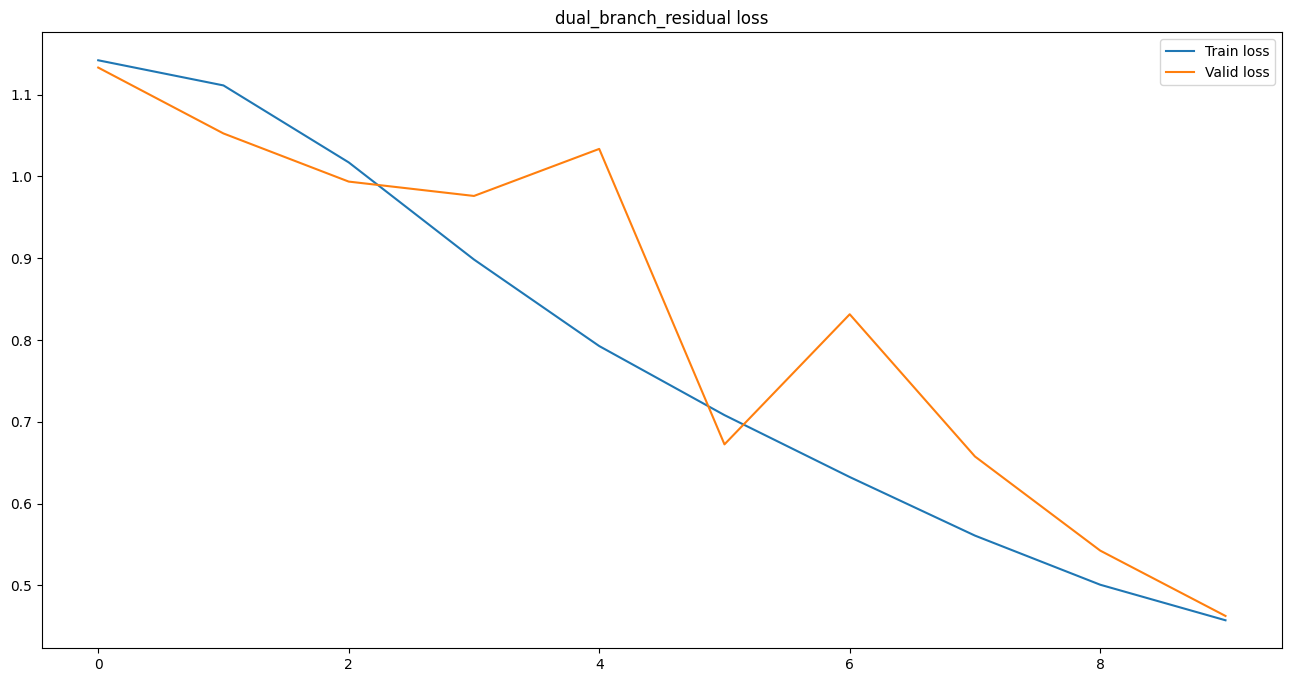

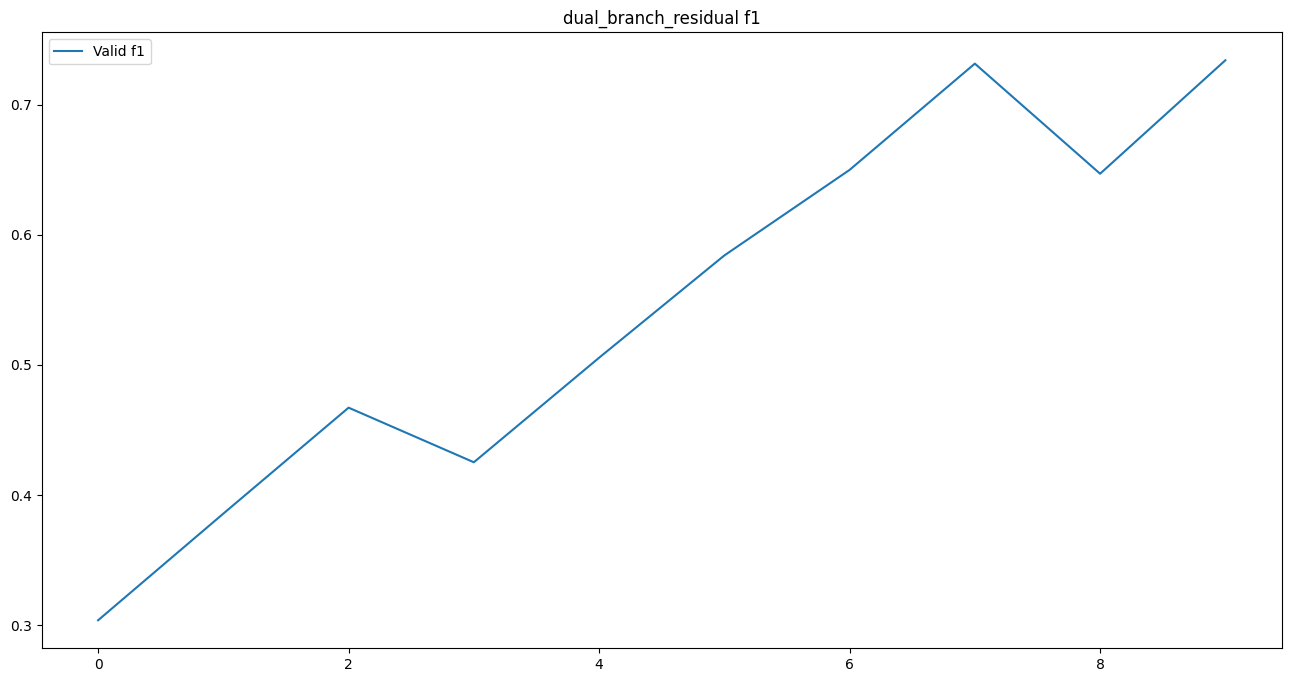

epoch=10/10 | train_loss=0.4573 | valid_loss=0.4625 | valid_f1=0.7343
best model epoch 9


100%|██████████| 157/157 [00:40<00:00,  3.91it/s]


In [31]:
model = DualBranchResidualNet().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

history = fit(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    optimizer=optimizer,
    loss_fn=criterion,
    device=device,
    num_epochs=10,
    title="dual_branch_residual"
)

submission = predict_test(
    model=model,
    test_loader=test_loader,
    device=device,
    threshold=0.45
)
submission.to_csv("submission.csv", index=False)